<a href="https://colab.research.google.com/github/rohillatanisha676-del/Machine-learning/blob/main/Ml_lab_02_Datapreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [17]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


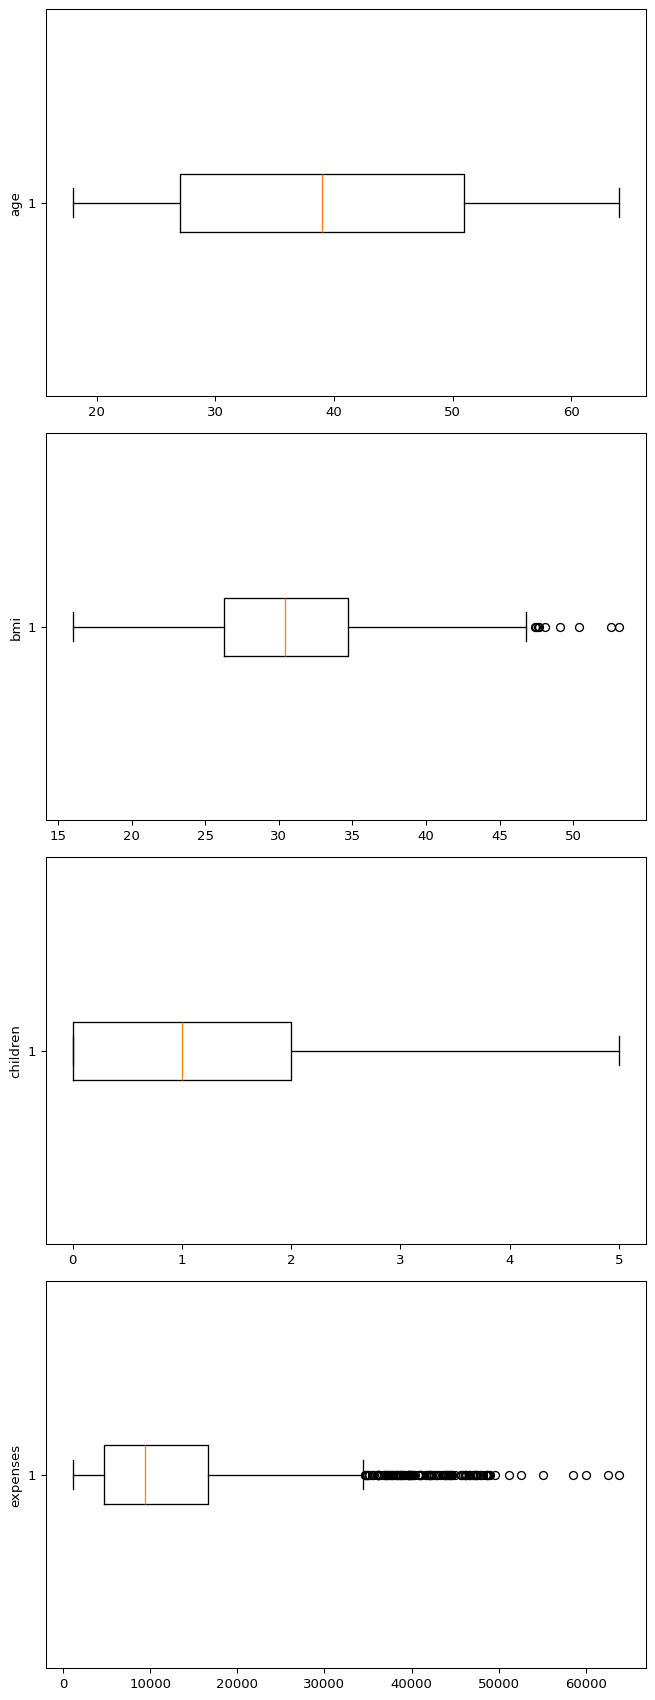

In [18]:
df.describe()

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axs = plt.subplots(len(numerical_cols), 1, figsize=(7, 18), dpi=95)

# Ensure axs is iterable even if there's only one numerical column
if len(numerical_cols) == 1:
    axs = [axs]

for i, col in enumerate(numerical_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [19]:
q1, q3 = np.percentile(df['bmi'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]


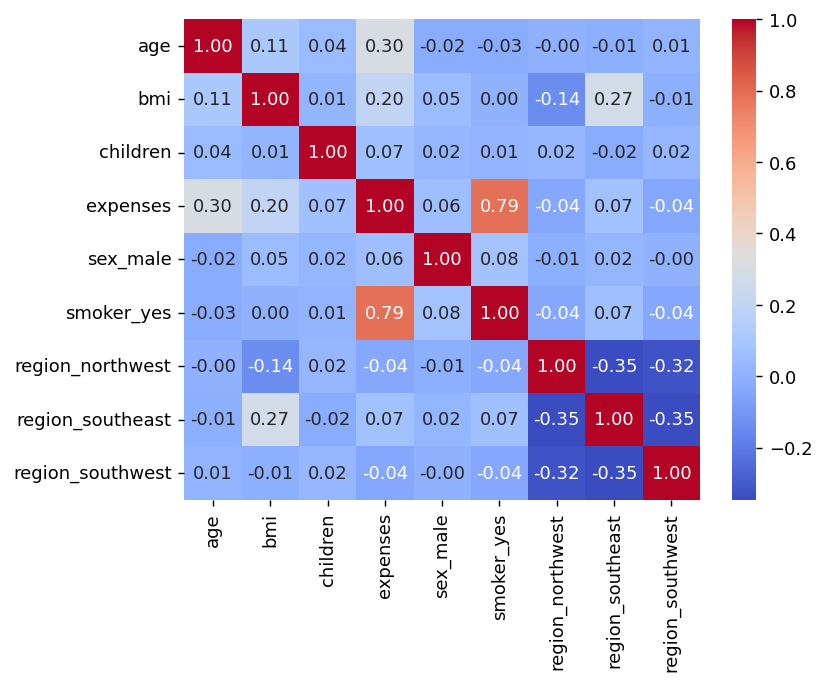

KeyError: 'charges'

In [20]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
corr = df_encoded.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()
# Assuming 'charges' is the target variable for correlation analysis
print(corr['charges'].sort_values(ascending=False))

In [ ]:
plt.pie(df['sex'].value_counts(), labels=df['sex'].value_counts().index, autopct='%.f%%', shadow=True)
plt.title('Sex Proportionality')
plt.show()

In [ ]:
X = df.drop(columns=['charges'])
y = df['charges']


X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_encoded)
print(X_normalized[:5])